In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings
import traceback

if '../' not in sys.path:
    sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

plt.style.use('../input/physrev.mplstyle')
plt.rcParams['figure.dpi'] = "300"

### directory with N_eff results

In [4]:
highmass = True

In [5]:
adm_results_dir = '/Users/duncan/scrap/adm_scans/adm_scan/'
if highmass:
    adm_results_dir = '/Users/duncan/scrap/adm_scans/adm_scan_highmass_notop/'

### Loop over directories to find all parameter points and load results

In [6]:
mde_dirs = []
mde_mdp_dirs = []

for name in os.listdir(adm_results_dir):
    if os.path.isdir(os.path.join(adm_results_dir, name)):
        mde_dirs.append(os.path.join(adm_results_dir, name))


for md in mde_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs.append(os.path.join(md, name))
    
    

In [7]:
N_Q = 50
num_param_points = len(mde_mdp_dirs*N_Q)

m_de = np.zeros(num_param_points)
m_dp = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)

R_Tnu_Tgam = np.zeros(num_param_points)
R_Tdark_Tgam = np.zeros(num_param_points)
R_Tgam_bsm_Tgam_sm = np.zeros(num_param_points)

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))
        result_txt_fname = rf.split('.npz')[0] + '.txt'

        #very hacky way to get temperature ratios from text files
        result_txt = np.genfromtxt(
            os.path.join(res_dir, rf.split('.npz')[0] + '.txt'), 
            delimiter='=', 
            skip_footer=1,
            usecols=1
        )

        ratio_Tnu_Tg = result_txt[8]
        ratio_Td_Tg = result_txt[9]
        ratio_Tgbsm_Tgsm = result_txt[10]

        R_Tnu_Tgam[res_ind] = ratio_Tnu_Tg
        R_Tdark_Tgam[res_ind] = ratio_Td_Tg
        R_Tgam_bsm_Tgam_sm[res_ind] = ratio_Tgbsm_Tgsm 
        

        m_de[res_ind] = result['m_de']
        m_dp[res_ind] = result['m_dp']
        charges[res_ind] = result['Q']
        N_eff[res_ind] = result['N_eff_bsm']
        Delta_N_eff[res_ind] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind] = result['DNeff_dso']


        res_ind += 1

failed_jobs = len(np.where(m_de == 0)[0])

In [8]:
sel = np.where(m_de > 0)

m_de = m_de[sel]
m_dp = m_dp[sel]
charges = charges[sel]
N_eff = N_eff[sel]
Delta_N_eff = Delta_N_eff[sel]
Delta_N_eff_dso = Delta_N_eff_dso[sel]

R_Tnu_Tgam = R_Tnu_Tgam[sel]
R_Tdark_Tgam = R_Tdark_Tgam[sel]
R_Tgam_bsm_Tgam_sm = R_Tgam_bsm_Tgam_sm[sel]

In [9]:
print(charges[1])
print(N_eff[1])
print(R_Tnu_Tgam[0])
print(R_Tdark_Tgam[0])
print(m_de[1])
print(m_dp[1])

1.389e-05
3.0862577802512514
0.714286818725247
0.006826167266256132
71970.0
71970.0


In [10]:
if highmass:
    resname = 'neff_scan_result_highmass.npz'
else:
    resname = 'neff_scan_result.npz'

np.savez_compressed(
    os.path.join('../output/results/',resname),
    m_de = m_de,
    m_dp = m_dp,
    eps = charges,
    N_eff = N_eff,
    R_Tnu_Tgam = R_Tnu_Tgam,
    R_Tdark_Tgam = R_Tdark_Tgam,
    R_Tgam_bsm_Tgam_sm = R_Tgam_bsm_Tgam_sm
    
)

### Plots

In [11]:
unique_mde = np.unique(m_de)

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()
Delta_N_eff_dso_interp_dict = dict()

for um_de in unique_mde:
    m_dp_um = m_dp[np.where(m_de == um_de)]

    unique_mdp = np.unique(m_dp_um)

    results_dict = dict()
    interp_dict = dict()
    interp_dict_dso = dict()

    for um_dp in unique_mdp:
        sel = np.where(
            (m_de == um_de)
           &(m_dp == um_dp)
        )

        charges_um_dp = charges[sel]
        N_eff_um_dp = N_eff[sel]
        Delta_N_eff_um_dp = Delta_N_eff[sel]
        Delta_N_eff_dso_um_dp = Delta_N_eff_dso[sel]

        sort_order = charges_um_dp.argsort()

        result_um_dp = np.array([
            charges_um_dp[sort_order], 
            N_eff_um_dp[sort_order],
            Delta_N_eff_um_dp[sort_order],
            Delta_N_eff_dso_um_dp[sort_order]
        ])

        #interpreter shouldn't have param points that failed
        Isel = np.where(N_eff_um_dp[sort_order] > 0.0)

        if np.any(N_eff_um_dp[sort_order] == 0.0):
            print('wtf')

        dne_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            Delta_N_eff_um_dp[sort_order][Isel], 
            bounds_error=False, 
            kind='cubic',
            fill_value=(Delta_N_eff_um_dp[sort_order][Isel][0], Delta_N_eff_um_dp[sort_order][Isel][-1])
        )

        dne_dso_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            Delta_N_eff_dso_um_dp[sort_order][Isel], 
            bounds_error=False, 
            fill_value=(Delta_N_eff_dso_um_dp[sort_order][Isel][0], Delta_N_eff_dso_um_dp[sort_order][Isel][-1])
        )

        results_dict = results_dict | {um_dp: result_um_dp}
        interp_dict = interp_dict | {um_dp: dne_I}
        interp_dict_dso = interp_dict_dso | {um_dp: dne_dso_I}

    N_eff_results_dict = N_eff_results_dict | {um_de: results_dict}
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um_de: interp_dict}
    Delta_N_eff_dso_interp_dict = Delta_N_eff_dso_interp_dict | {um_de: interp_dict_dso}

In [12]:
print(unique_mde)

[3.089e+02 3.728e+02 4.498e+02 5.429e+02 6.551e+02 7.906e+02 9.541e+02
 1.151e+03 1.389e+03 1.677e+03 2.024e+03 2.442e+03 2.947e+03 3.556e+03
 4.292e+03 5.179e+03 6.251e+03 7.543e+03 9.103e+03 1.099e+04 1.326e+04
 1.600e+04 1.931e+04 2.330e+04 2.812e+04 3.393e+04 4.095e+04 4.942e+04
 5.964e+04 7.197e+04 8.685e+04 1.048e+05 1.265e+05 1.526e+05 1.842e+05
 2.223e+05 2.683e+05 3.237e+05 3.907e+05 4.715e+05 5.690e+05 6.866e+05
 8.286e+05 1.000e+06]


In [13]:
eps_min = 1e-10
eps_max = 1e-4

num_eps = 50
charge_list = np.geomspace(eps_min, eps_max, num_eps)

## Make Neff contour plot in hydrogen and positronium limits

In [14]:
masses_HL = np.zeros((len(unique_mde), N_Q))
charges_HL = np.zeros((len(unique_mde), N_Q))
N_eff_HL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    HL_mdp_key = list(N_eff_results_dict[mass_de].keys())[-1]
    charges = N_eff_results_dict[mass_de][HL_mdp_key][0]
    N_eff = N_eff_results_dict[mass_de][HL_mdp_key][1]

    #in case of failed jobs
    num_completed = len(N_eff)

    masses_HL[i, :] = mass_de
    charges_HL[i, :] = charge_list 
    N_eff_HL[i, 0:num_completed] = N_eff

masses_PL = np.zeros((len(unique_mde), N_Q))
charges_PL = np.zeros((len(unique_mde), N_Q))
N_eff_PL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    PL_mdp_key = list(N_eff_results_dict[mass_de].keys())[0]
    N_eff = N_eff_results_dict[mass_de][PL_mdp_key][1]

    #in case of failed jobs
    num_completed = len(N_eff)

    masses_PL[i, :] = mass_de
    charges_PL[i, :] = charge_list 
    N_eff_PL[i, 0:num_completed] = N_eff

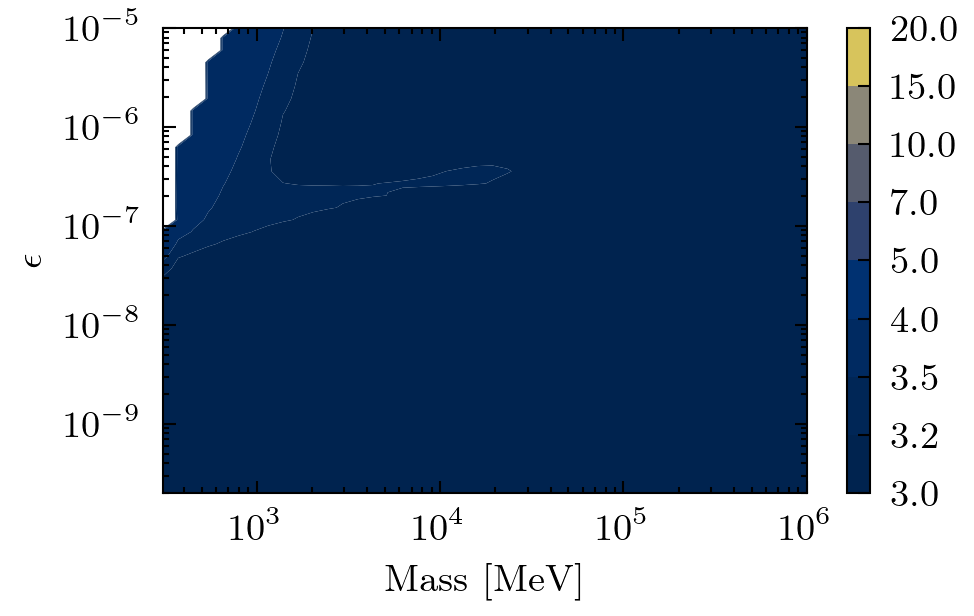

In [15]:
f, ax = plt.subplots(1, 1)
contour_levels = np.array([3.0, 3.2, 3.5, 4, 5, 7, 10, 15, 20])

plt.contourf(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels,
    antialiased=True,
    # norm='log',
    cmap='cividis'
)

plt.colorbar()

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.ylim(2e-10, 1e-5)

plt.xscale('log')
plt.yscale('log')

plt.savefig('../output/figures/N_eff_contour_HL.pdf')

plt.show()

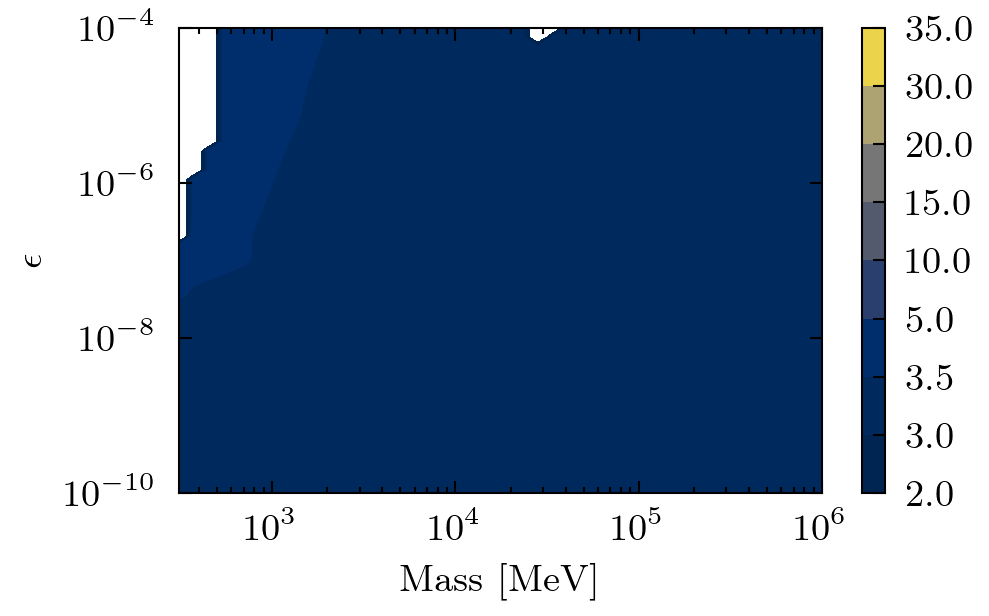

In [16]:
f, ax = plt.subplots(1, 1)

contour_levels = np.array([2.0, 3.0, 3.5, 5, 10, 15, 20, 30, 35])
# contour_levels = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])


# contour_levels = np.array([3.0, 3.5, 4.0, 5.0])

plt.contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels,
    # antialiased=True,
    # norm='log',
    cmap='cividis'
)

plt.colorbar()

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

# plt.ylim(2e-10, 3e-6)
plt.xscale('log')
plt.yscale('log')

# plt.plot(masses_bad, charges_bad, linestyle='none', marker='+')
plt.savefig('../output/figures/N_eff_contour_PL.pdf')
plt.show()

## Constraint contours

In [17]:
def get_DNeff_constraint_RHS(delta_neff_Interp, constraint):
    return lambda Q: delta_neff_Interp(Q) - constraint

def find_Q_DNeff_constraint(delta_neff_Interp, constraint, Q_min=1e-10, Q_max = 1e-4, Q_0=1e-9):
    Q_min = delta_neff_Interp.x[0]
    Q_max = delta_neff_Interp.x[-1]    
    
    try:
        constraint_res = root_scalar(
         get_DNeff_constraint_RHS(delta_neff_Interp, constraint),
         # bracket=(Q_min, Q_max),
         bracket=(Q_min, Q_max),
         x0=Q_0,
         method='brenth'
    )
        return constraint_res.root
    except Exception as e:
        print(e)
        return np.nan

In [18]:
Q_Neff_0_06_HL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_HL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_16_HL = np.zeros(len(Delta_N_eff_interp_dict.keys()))


Q_Neff_0_06_PL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_PL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_16_PL = np.zeros(len(Delta_N_eff_interp_dict.keys()))

Q_Neff_0_06_HL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_HL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))

Q_Neff_0_06_PL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_PL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))

dark_electron_masses = np.array(list(Delta_N_eff_interp_dict.keys()))


for (i, mass) in enumerate(Delta_N_eff_interp_dict.keys()):
      HL_key = list(Delta_N_eff_interp_dict[mass].keys())[-1]
      PL_key = list(Delta_N_eff_interp_dict[mass].keys())[0]


    
      Q_Neff_0_06_HL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][HL_key], 0.06)
      Q_Neff_0_027_HL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][HL_key], 0.027)
      Q_Neff_0_16_HL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][HL_key], 0.16)
    
      Q_Neff_0_06_PL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][PL_key], 0.06)
      Q_Neff_0_027_PL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][PL_key], 0.027)
      Q_Neff_0_16_PL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][PL_key], 0.16)

      Q_Neff_0_06_HL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][HL_key], 0.06)
      Q_Neff_0_027_HL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][HL_key], 0.027)
    
      Q_Neff_0_06_PL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][PL_key], 0.06)
      Q_Neff_0_027_PL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][PL_key], 0.027)

      if i == 38:
          print(HL_key)
          print(PL_key)
          print(Q_Neff_0_06_HL[i])
          print(Q_Neff_0_06_PL[i])

f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs
f(a) and f(b) must have different signs


In [19]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

shelton_neff_const_0_06 = load_csv('../input/fig/2206.13530_fig1_0_06_lower_branch.csv')
shelton_neff_const_0_027 = load_csv('../input/fig/2206.13530_fig1_0_027.csv')

In [20]:
print(f'{dark_electron_masses[39]:.3e}')
test_mass = dark_electron_masses[39]

4.715e+05


In [21]:
Q_Neff_0_06_HL[38]

1.2356841518486297e-06

1.347804226132279e-06

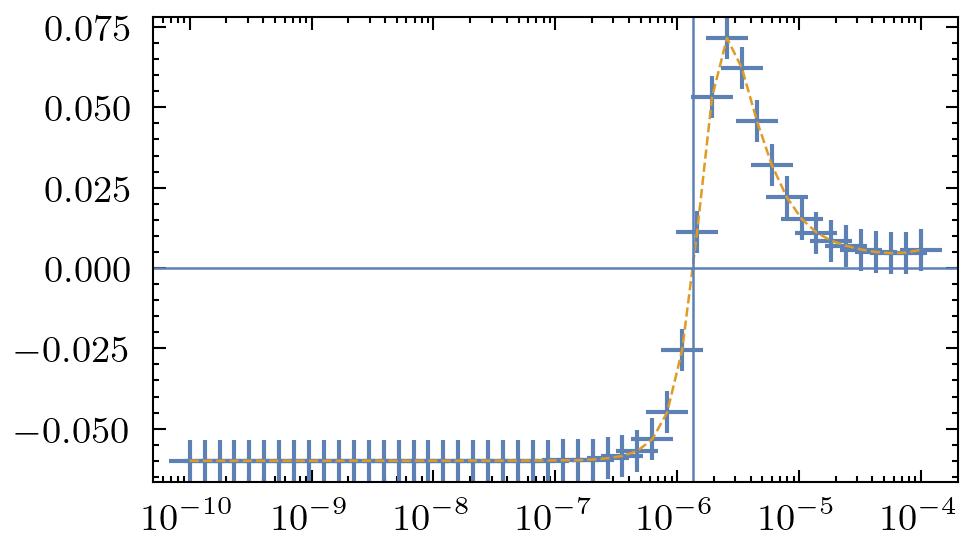

In [23]:
plt.plot(Delta_N_eff_interp_dict[test_mass][1000*test_mass].x, 
         Delta_N_eff_interp_dict[test_mass][1000*test_mass].y - 0.06, 
         linestyle='none',
        marker='+')

plt.plot(Delta_N_eff_interp_dict[test_mass][1000*test_mass].x, 
         Delta_N_eff_interp_dict[test_mass][1000*test_mass].y - 0.06, 
        )
plt.axhline(0.0)
plt.axvline(1.346869145502236e-06)
plt.xscale('log')

find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[test_mass][test_mass*1000], 0.06)

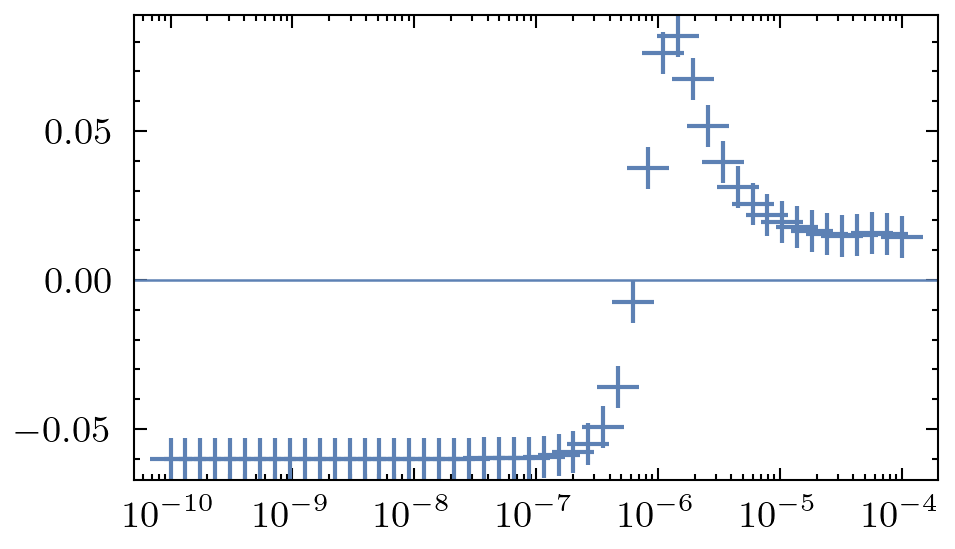

In [24]:
plt.plot(
    Delta_N_eff_interp_dict[1.048e+05][1000*1.048e+05].x, 
    Delta_N_eff_interp_dict[1.048e+05][1000*1.048e+05].y - 0.06,
    linestyle='none',
    marker='+'
)
plt.axhline(0.0)
plt.xscale('log')

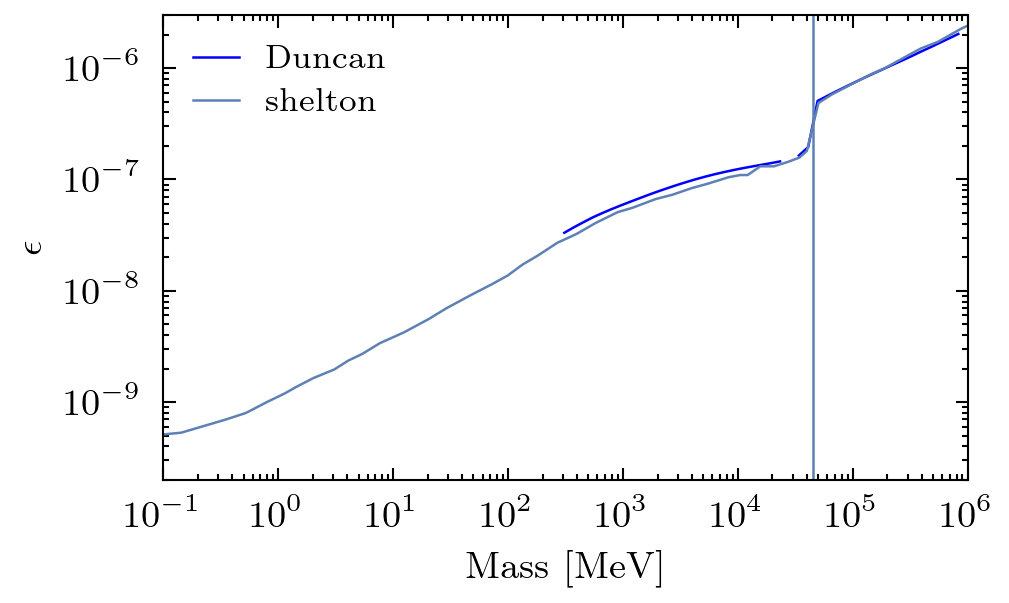

In [31]:

s2_theta_w = 0.22339 
c2_theta_w = 1-s2_theta_w
plt.plot(dark_electron_masses, Q_Neff_0_06_HL*np.sqrt(1/c2_theta_w), color='blue', linestyle='solid', label='Duncan')
# plt.plot(dark_electron_masses, Q_Neff_0_027_HL, color='blue', linestyle='dashed')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL, color='green', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.027')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL_DSO, color='red', linestyle='dotted')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL_DSO, color='green', linestyle='dotted')

plt.plot(*shelton_neff_const_0_06, label='shelton')
# plt.plot(*shelton_neff_const_0_027)

plt.xlim(0.1, 1e6)
plt.ylim(2e-10, 3e-6)



# plt.xlim(1e4, 1e6)
# plt.ylim(5e-7, 3e-6)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.axvline(90*1e3/2)

plt.legend()
# plt.title(r'$\Delta N_{\rm eff}$ constraints; Full (solid) vs Dark Sector Only (dotted)')

# plt.savefig('../output/figures/delta_neff_constraint_full_vs_dso.pdf')


plt.show()

In [ ]:
plt.plot(dark_electron_masses, Q_Neff_0_06_HL, color='blue', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; HL')
plt.plot(dark_electron_masses, Q_Neff_0_027_HL, color='blue', linestyle='dashed', label=r'$\Delta N_{\rm eff}$ = 0.027; HL')

plt.plot(dark_electron_masses, Q_Neff_0_06_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; PL')
plt.plot(dark_electron_masses, Q_Neff_0_027_PL, color='red', linestyle='dashed', label=r'$\Delta N_{\rm eff}$ = 0.027; PL')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL_DSO, color='red', linestyle='dotted')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL_DSO, color='green', linestyle='dotted')

# plt.plot(*shelton_neff_const_0_06)
# plt.plot(*shelton_neff_const_0_027)

plt.xlim(1, 100)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.legend()
plt.title(r'$\Delta N_{\rm eff}$ constraints; Hydrogen vs Positronium Limits')

plt.savefig('../output/figures/delta_neff_constraint_HL_PL.pdf')

plt.show()

In [ ]:
plt.plot(dark_electron_masses, Q_Neff_0_06_HL_DSO, color='blue', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; HL')
plt.plot(dark_electron_masses, Q_Neff_0_027_HL_DSO, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.027; HL')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; PL')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL, color='red', linestyle='dashed', label=r'$\Delta N_{\rm eff}$ = 0.027; PL')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL_DSO, color='red', linestyle='dotted')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL_DSO, color='green', linestyle='dotted')

plt.plot(*shelton_neff_const_0_06, color='blue', linestyle='dotted', label=r'$\Delta N_{\rm eff}$ = 0.06; Shelton')
plt.plot(*shelton_neff_const_0_027, color='red', linestyle='dotted', label=r'$\Delta N_{\rm eff}$ = 0.027; Shelton')

plt.xlim(1, 100)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.legend()
plt.title(r'$\Delta N_{\rm eff}$ constraints; Duncan HL DSO vs Shelton')

plt.savefig('../output/figures/delta_neff_constraint_HL_shelton.pdf')

plt.show()

In [ ]:
plt.plot(dark_electron_masses, Q_Neff_0_16_HL, color='blue', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; HL')
plt.plot(dark_electron_masses, Q_Neff_0_16_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.027; HL')
plt.xlim(0.1, 1e6)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

for mtest in np.geomspace(100, 1e6):
    plt.axvline(mtest)

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

### Miscellaneous stuff

In [ ]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys()):
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend()
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()

In [ ]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys())[::2]:
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend(loc=4)
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()

In [ ]:
for m_de_plot in unique_mde:
    m_dp_plot_HL = list(N_eff_results_dict[m_de_plot].keys())[-1]
    charge = N_eff_results_dict[m_de_plot][m_dp_plot_HL][0][5]
    N_eff_BSM = N_eff_results_dict[m_de_plot][m_dp_plot_HL][1][5]
    plt.plot(m_de_plot, N_eff_BSM, marker='+', color='blue')
    plt.xscale('log')

plt.xlabel('m_e [MeV]')
plt.ylabel('N_eff')
plt.title('m_dp = 1000 m_de; eps = 4.095e-10')

In [ ]:
print(N_eff_results_dict[1e6][1000*1e6][0][5])
print(N_eff_results_dict[1e6][1000*1e6][1][5])

In [ ]:
 N_eff_BSM 

In [ ]:
for m_de_plot in unique_mde:
    m_dp_plot_HL = list(N_eff_results_dict[m_de_plot].keys())[0]
    # print(list(N_eff_results_dict[m_de_plot].keys()))
    charge = N_eff_results_dict[m_de_plot][m_dp_plot_HL][0][0]
    # print(charge)
    N_eff_BSM = N_eff_results_dict[m_de_plot][m_dp_plot_HL][1][0]
    plt.plot(m_de_plot, N_eff_BSM, marker='+', color='blue')
    plt.xscale('log')

plt.xlabel('m_e [MeV]')
plt.ylabel('N_eff')
plt.title('m_dp = 1000 m_de; eps = 4.095e-10')